# Explainability

SHAP feature importance (global + per-customer) for LightGBM, followed by a
small GenAI demo that converts SHAP output into a plain-language explanation
for a non-technical stakeholder.

In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.modeling.train import get_xy, build_lightgbm
from churn.explainability.shap_analysis import fit_explainer, get_top_customers_by_risk, explain_customer

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

model = build_lightgbm().fit(X_train, y_train)
explainer = fit_explainer(model, X_train)

## Global feature importance (SHAP summary plot)

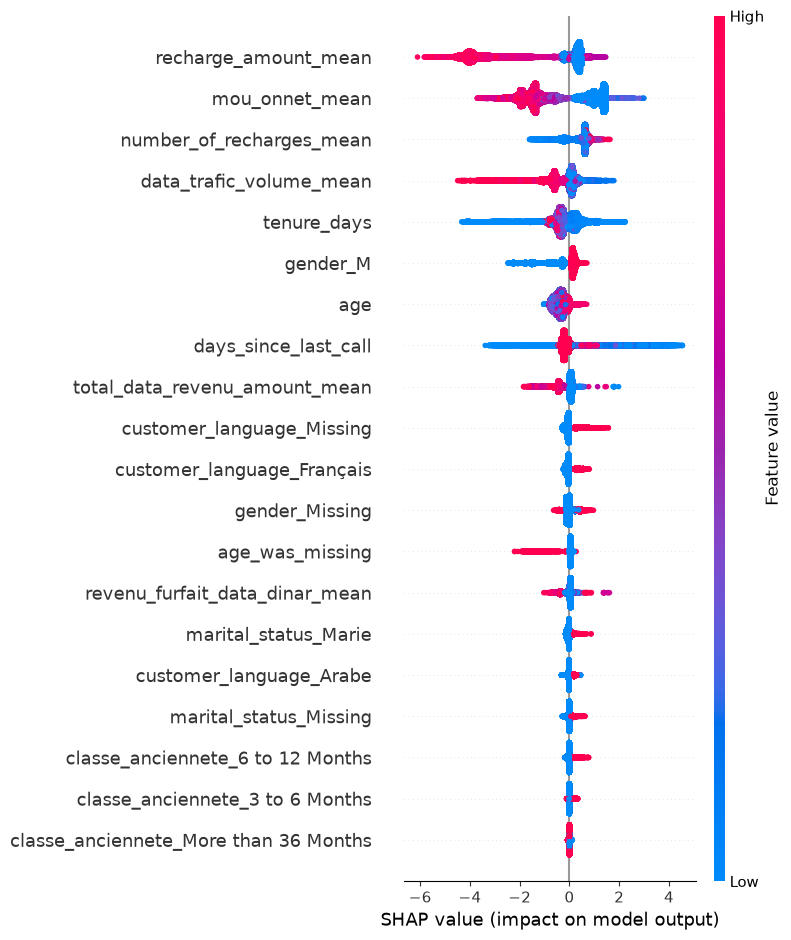

In [2]:
shap_values_test = explainer(X_test)

fig = plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.tight_layout()
save_fig(fig, "15_shap_summary")
plt.show()

**Observations:**

## Per-customer explanation — example flagged customers

        predicted_proba
55310          0.987610
104526         0.984339
6434           0.983119
                            feature     value  shap_value
6              days_since_last_call      49.0    2.078881
7                       tenure_days        50    1.680829
0              recharge_amount_mean  6.908755    0.827344
18       customer_language_Français      True    0.527983
3           data_trafic_volume_mean       0.0    0.489502
2                    mou_onnet_mean  3.433987   -0.276740
21  classe_anciennete_3 to 6 Months      True    0.223653
10                         gender_M      True    0.209453
14             marital_status_Marie     False   -0.120656
1          number_of_recharges_mean       1.0   -0.099915


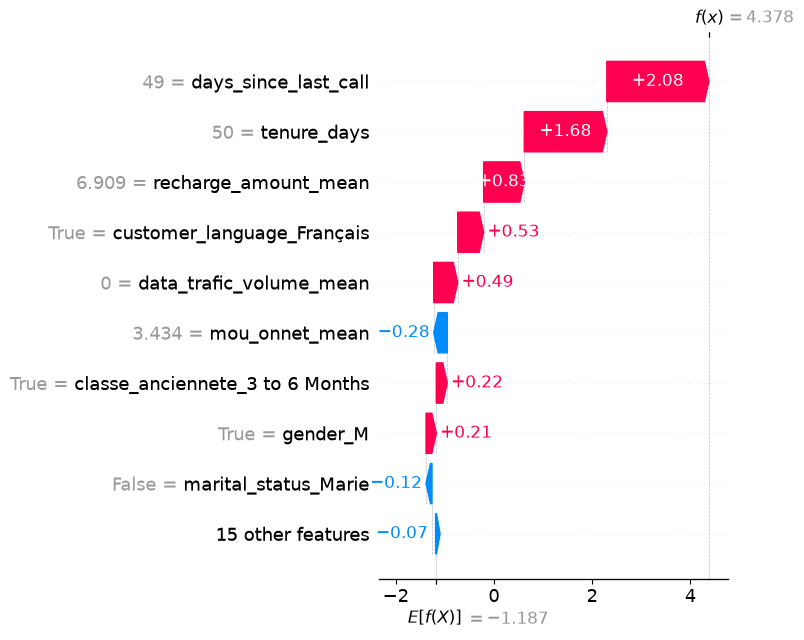

In [3]:
WORKING_THRESHOLD = 0.38  # LightGBM, 5:1 cost ratio, from step 9

top_customers = get_top_customers_by_risk(model, X_test, threshold=WORKING_THRESHOLD, n=3)
print(top_customers[["predicted_proba"]])

example_customer = X_test.loc[[top_customers.index[0]]]
customer_explanation = explain_customer(explainer, example_customer)
print(customer_explanation.head(10))

fig = plt.figure(figsize=(8, 6))
shap.plots.waterfall(explainer(example_customer)[0], show=False)
plt.tight_layout()
save_fig(fig, "16_shap_waterfall_example_customer")
plt.show()

In [4]:
train = pd.read_parquet(PROCESSED_DIR / "train_selected.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
print("train days_since_last_call range:", train["days_since_last_call"].min(), "-", train["days_since_last_call"].max())
print("test days_since_last_call range:", test["days_since_last_call"].min(), "-", test["days_since_last_call"].max())

train days_since_last_call range: 0.0 - 91.0
test days_since_last_call range: 0.0 - 91.0
